<a href="https://colab.research.google.com/github/krishRajawat/My-Google-Colab-Work/blob/main/EcoPulse_by_Krish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prediction Accuracy (MAE): 1.20 kW


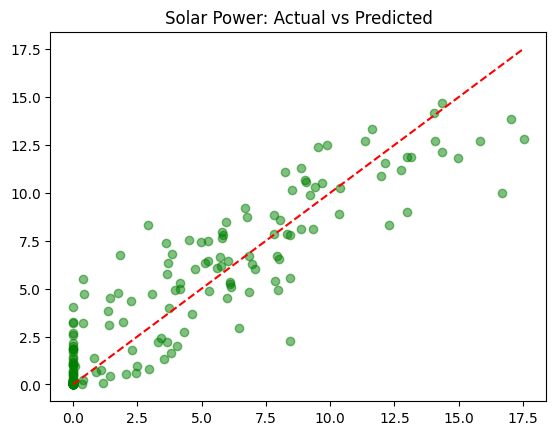

In [ ]:
# =======================================================================
# "EcoPulse: Solar Energy Forecasting & Optimization System"
# Author: Krish Rajawat
# =======================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. GENERATE SYNTHETIC SOLAR DATA (Emulating real sensors)
# Features: Temp, Humidity, Cloud Cover, Hour of Day
np.random.seed(42)
data_size = 1000
temp = np.random.uniform(20, 40, data_size)
humidity = np.random.uniform(30, 90, data_size)
clouds = np.random.uniform(0, 100, data_size)
hour = np.random.randint(6, 19, data_size) # Only daylight hours

# Target: Power Output (kW) - Simple logic: High Temp + Low Clouds = High Power
power = (temp * 0.5) - (clouds * 0.2) - (humidity * 0.1) + (hour * 0.3) + np.random.normal(0, 2, data_size)
power = np.maximum(power, 0) # Power cannot be negative

df = pd.DataFrame({'Temp': temp, 'Humidity': humidity, 'Clouds': clouds, 'Hour': hour, 'Output': power})

# 2. MODELING
X = df.drop('Output', axis=1)
y = df['Output']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# 3. PREDICTION & VISUALIZATION
y_pred = model.predict(X_test)
print(f"Prediction Accuracy (MAE): {mean_absolute_error(y_test, y_pred):.2f} kW")

plt.scatter(y_test, y_pred, color='green', alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.title("Solar Power: Actual vs Predicted")
plt.show()

I used weather data (temperature, humidity) to predict how much electricity a solar panel will produce.